# Mini Project 1: Cobblestone Gifts Cleaning Project


In [239]:
import kagglehub
import pandas as pd
import numpy as np
import re

## PHASE A · Load & profile
This section will load the raw dataset, inspect its shape and structure, and record the first data-quality issues that need attention.

In [240]:
class DataLoader:
    def __init__(self, data_source):
        self.data_source = data_source
        self.path = None        
    
    def download_kaggle(self):
        """
        Downloads a dataset from Kaggle.

        :param dataset_name: The name of the dataset to download.
        """
        print(f"Downloading {self.data_source} from Kaggle...")
        self.path = kagglehub.dataset_download(self.data_source)
        return self.path

    def load_data(self):
        """
        Loads data from the specified data source.

        :return: Loaded data.
        """
        print(f"Loading data from {self.path}")
        self.df = pd.read_csv(f"{self.path}/data.csv", encoding='ISO-8859-1')
        # This section should report the dataset shape, inspect the first rows, and summarize the column types, missing values, and overall data quality using `head()`, `shape`, `info()`, and `describe()`.
        print(f"Dataset shape: {self.df.shape}")
        print("First 4 rows:")
        print(self.df.head(4))
        print(f"Data types and missing values:\n{self.df.info()}")
        print(f"Data quality summary:\n{self.df.describe()}")
        return self.df  
    
    def unique_count(self, columns):
        """
        Counts unique values in specified columns.
        
        :param columns: List of column names to analyze.
        """
        for column in columns:
            print(f"Total number of uique values in {column}: {self.df[column].nunique()}")
            print(f"Unique values and counts in {column}:\n{self.df[column].value_counts(dropna=False)}")
            
    def summary_statistics(self, columns):
        """
        Provides summary statistics for specified columns.
        
        :param columns: List of column names to analyze.
        """
        for column in columns:
            print(f"Summary statistics for {column}")
            print(f"Min: {self.df[column].min()}, Max: {self.df[column].max()}, Sum: {self.df[column].sum()}, Mean: {self.df[column].mean()}, Count: {self.df[column].count()}")
            
    
    def identify_negative_zero(self, columns):
        """
        Identifies negative and zero values in specified numeric columns.
        
        :param columns: List of numeric column names to analyze.
        """
        for column in columns:
            if pd.api.types.is_numeric_dtype(self.df[column]):
                negative_count = (self.df[column] < 0).sum()
                zero_count = (self.df[column] == 0).sum()
                print(f"Column {column}: Negative values count = {negative_count}, Zero values count = {zero_count}")
            else:
                print(f"Column {column} is not numeric and will be skipped.")

### 3.2 Getting information
Load the raw CSV with the correct encoding, then record shape, preview rows, data types, summary statistics, and missing-value counts for every column.

In [241]:
# Loading carrie1/ecommerce-data
data_loader = DataLoader("carrie1/ecommerce-data")
data_loader.download_kaggle()
df = data_loader.load_data()
print()

Loading data from C:\Users\gauravkh\.cache\kagglehub\datasets\carrie1\ecommerce-data\versions\1
Dataset shape: (541909, 8)
First 4 rows:
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoic

### 3.9 Unique values
Use `value_counts()` and `nunique()` on Country, StockCode, and Description to identify non-product codes, missing labels, and unusual category patterns.

In [242]:
data_loader.unique_count(['Country', 'StockCode', 'Description'])

Total number of uique values in Country: 38
Unique values and counts in Country:
Country
United Kingdom          495478
Germany                   9495
France                    8557
EIRE                      8196
Spain                     2533
Netherlands               2371
Belgium                   2069
Switzerland               2002
Portugal                  1519
Australia                 1259
Norway                    1086
Italy                      803
Channel Islands            758
Finland                    695
Cyprus                     622
Sweden                     462
Unspecified                446
Austria                    401
Denmark                    389
Japan                      358
Poland                     341
Israel                     297
USA                        291
Hong Kong                  288
Singapore                  229
Iceland                    182
Canada                     151
Greece                     146
Malta                      127
United Arab 

### 3.8 Min/max/sum/mean/count
Summarize Quantity and UnitPrice to identify negative quantities, zero prices, and other impossible values that cannot represent valid sales.

In [243]:
data_loader.summary_statistics(['Quantity', 'UnitPrice'])

Summary statistics for Quantity
Min: -80995, Max: 80995, Sum: 5176450, Mean: 9.55224954743324, Count: 541909
Summary statistics for UnitPrice
Min: -11062.06, Max: 38970.0, Sum: 2498803.974, Mean: 4.611113626088513, Count: 541909


### 3.1 Creating a DataFrame
Build a small country → region lookup table from a Python dictionary (e.g. United
Kingdom → UK\&IE; France, Germany → Western Europe). 

In [244]:
region_map = {
    'UK&IE': ['United Kingdom', 'Ireland'],
    'Western Europe': ['France', 'Germany', 'Belgium'],
    'Nordics': ['Sweden', 'Norway', 'Denmark']
}

lookup_table = pd.DataFrame([
    {'Country': country, 'Region': region}
    for region, countries in region_map.items()
    for country in countries
])

## PHASE B · Slice, filter & sort
This section explores the raw DataFrame using positional and label-based indexing, conditional filters, and sorting.

In [245]:
class DataExplorer:
    """Phase B — slice, filter, and sort the raw DataFrame."""

    def add_line_item_id(self, df):
        """3.3 Add a LineItemID index (L0, L1, ...) for label-based access."""
        df = df.copy()
        df["LineItemID"] = ["L" + str(i) for i in range(len(df))]
        return df.set_index("LineItemID")

    def slice_iloc(self, df):
        """3.3 Positional slices: first 5 rows, rows 100-110, last 5, and a 5x4 block."""
        print("First 5 rows:"); print(df.iloc[0:5])
        print("Rows 100-110:"); print(df.iloc[100:110])
        print("Last 5 rows:"); print(df.iloc[-5:])
        print("First 5 rows, first 4 columns:"); print(df.iloc[0:5, 0:4])

    def slice_loc(self, df):
        """3.3 Label-based access: single key, range, list, and boolean mask."""
        print(df.loc["L100"])
        print(df.loc["L100":"L105"])
        print(df.loc[["L0", "L50", "L999"], ["StockCode", "Description", "Quantity"]])
        print(df.loc[df["Quantity"] < 0, ["InvoiceNo", "StockCode", "Quantity"]])

    def filter(self, df):
        """3.4 Conditional selection: cancellations, non-positive quantity, non-positive price."""
        cancellations = df[df["InvoiceNo"].astype(str).str.startswith("C")]
        print(f"Cancellations (InvoiceNo starts with C): {len(cancellations)}")
        qty_non_positive = df[df["Quantity"] <= 0]
        print(f"Quantity <= 0: {len(qty_non_positive)}")
        price_non_positive = df[df["UnitPrice"] <= 0]
        print(f"UnitPrice <= 0: {len(price_non_positive)}")

    def sort(self, df):
        """3.5 Sort by Quantity and LineRevenue to surface bulk orders and large returns."""
        df = df.copy()
        df["LineRevenue"] = df["Quantity"] * df["UnitPrice"]
        cols = ["InvoiceNo", "StockCode", "Description", "Quantity", "UnitPrice", "LineRevenue"]
        print("Largest bulk orders (by Quantity):")
        print(df.sort_values("Quantity", ascending=False)[cols].head(10))
        print("\nLargest returns (by Quantity):")
        print(df.sort_values("Quantity", ascending=True)[cols].head(10))
        print("\nLargest line revenue:")
        print(df.sort_values("LineRevenue", ascending=False)[cols].head(10))
        print("\nLargest revenue losses:")
        print(df.sort_values("LineRevenue", ascending=True)[cols].head(10))
        return df


### 3.3 Slicing

In [246]:
explorer = DataExplorer()
indexed_df = explorer.add_line_item_id(df)
explorer.slice_iloc(indexed_df)


First 5 rows:
           InvoiceNo StockCode                          Description  Quantity  \
LineItemID                                                                      
L0            536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
L1            536365     71053                  WHITE METAL LANTERN         6   
L2            536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
L3            536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
L4            536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

               InvoiceDate  UnitPrice  CustomerID         Country  
LineItemID                                                         
L0          12/1/2010 8:26       2.55     17850.0  United Kingdom  
L1          12/1/2010 8:26       3.39     17850.0  United Kingdom  
L2          12/1/2010 8:26       2.75     17850.0  United Kingdom  
L3          12/1/2010 8:26       3.39     17850.0  United Kingdom  
L4        

In [247]:
explorer.slice_loc(indexed_df)


InvoiceNo                               536378
StockCode                               84519A
Description    TOMATO CHARLIE+LOLA COASTER SET
Quantity                                     6
InvoiceDate                     12/1/2010 9:37
UnitPrice                                 2.95
CustomerID                             14688.0
Country                         United Kingdom
Name: L100, dtype: object
           InvoiceNo StockCode                          Description  Quantity  \
LineItemID                                                                      
L100          536378    84519A      TOMATO CHARLIE+LOLA COASTER SET         6   
L101          536378    85183B  CHARLIE & LOLA WASTEPAPER BIN FLORA        48   
L102          536378    85071B   RED CHARLIE+LOLA PERSONAL DOORSIGN        96   
L103          536378     21931               JUMBO STORAGE BAG SUKI        10   
L104          536378     21929       JUMBO BAG PINK VINTAGE PAISLEY        10   
L105          536380     22961 

### 3.4 Conditional Selection

In [248]:
explorer.filter(indexed_df)


Cancellations (InvoiceNo starts with C): 9288
Quantity <= 0: 10624
UnitPrice <= 0: 2517


### 3.5 Sorting Values

In [249]:
indexed_df = explorer.sort(indexed_df)


Largest bulk orders (by Quantity):
           InvoiceNo StockCode                          Description  Quantity  \
LineItemID                                                                      
L540421       581483     23843          PAPER CRAFT , LITTLE BIRDIE     80995   
L61619        541431     23166       MEDIUM CERAMIC TOP STORAGE JAR     74215   
L502122       578841     84826       ASSTD DESIGN 3D PAPER STICKERS     12540   
L74614        542504     37413                                  NaN      5568   
L421632       573008     84077    WORLD WAR 2 GLIDERS ASSTD DESIGNS      4800   
L206121       554868     22197                 SMALL POPCORN HOLDER      4300   
L220843       556231    85123A                                    ?      4000   
L97432        544612     22053                EMPIRE DESIGN ROSETTE      3906   
L270885       560599     18007  ESSENTIAL BALM 3.5g TIN IN ENVELOPE      3186   
L160546       550461     21108   FAIRY CAKE FLANNEL ASSORTED COLOUR      3

## Phase C Clean and Fix


In [250]:
class DataCleaner:
    """Phase C — one method per cleaning step, each callable independently."""

    def replace_values(self, df, column, replacements):
        """3.6 Replace specific values in a column."""
        df = df.copy()
        df[column] = df[column].replace(replacements)
        return df

    def rename_columns(self, df, overrides=None):
        """3.7 Rename all columns to snake_case, with optional explicit overrides."""
        df = df.copy()
        def to_snake(name):
            name = re.sub(r'(?<!^)(?=[A-Z])', '_', name)
            return name.lower()
        df = df.rename(columns={col: to_snake(col) for col in df.columns})
        if overrides:
            df = df.rename(columns=overrides)
        return df

    def handle_missing(self, df, drop_cols=None, fill_map=None):
        """3.10 Drop rows missing required columns; fill optional columns."""
        df = df.copy()
        if drop_cols:
            for col in drop_cols:
                if col in df.columns and (pd.api.types.is_string_dtype(df[col])
                                          or df[col].dtype == object):
                    df[col] = df[col].str.strip().replace('', np.nan)
            df = df.dropna(subset=drop_cols)
        for col, val in (fill_map or {}).items():
            if col in df.columns:
                df[col] = df[col].fillna(val)
        return df

    def drop_columns(self, df, columns):
        """3.11 Delete one or more columns."""
        df = df.copy()
        return df.drop(columns=[c for c in columns if c in df.columns])

    def delete_rows(self, df, invoice_col='invoice_no', stock_col='stock_code',
                    qty_col='quantity', price_col='unit_price',
                    non_product_codes=('POST', 'DOT', 'M', 'BANK CHARGES', 'AMAZONFEE')):
        """3.12 Drop rows to build a clean sales DataFrame"""
        df = df.copy()
        # cancellations
        df = df[~df[invoice_col].astype(str).str.startswith('C')]
        # non-product lines: drop the named admin/non-product stock codes
        blacklist = {c.strip().upper() for c in non_product_codes}
        stock_norm = df[stock_col].astype(str).str.strip().str.upper()
        df = df[~stock_norm.isin(blacklist)]
        # impossible quantities / prices
        df = df[(df[qty_col] > 0) & (df[price_col] > 0)]
        return df

    def drop_duplicates(self, df):
        """3.13 Detect and remove exact duplicate rows; report how many were dropped."""
        df = df.copy()
        n_dupes = df.duplicated().sum()
        out = df.drop_duplicates()
        print(f"Exact duplicate rows: {n_dupes:,}")
        print(f"Rows before: {len(df):,}, after: {len(out):,} (dropped {len(df) - len(out):,})")
        return out


cleaner = DataCleaner()


### 3.6 Replacing Values

In [251]:
# Keep the raw DataFrame untouched; build the clean version as a new object.
raw_df = df.copy()     # immutable snapshot of the raw export
work_df = df.copy()    # working copy we clean step by step

# Derived helper used during cleaning/exploration; dropped from the clean table in 3.11.
work_df["LineRevenue"] = work_df["Quantity"] * work_df["UnitPrice"]

# 3.6 Standardise country labels
work_df = cleaner.replace_values(work_df, column='Country', replacements={
    'EIRE': 'Ireland',
    'RSA': 'South Africa',
    'Unspecified': np.nan,
})

print(work_df['Country'].value_counts(dropna=False))


Country
United Kingdom          495478
Germany                   9495
France                    8557
Ireland                   8196
Spain                     2533
Netherlands               2371
Belgium                   2069
Switzerland               2002
Portugal                  1519
Australia                 1259
Norway                    1086
Italy                      803
Channel Islands            758
Finland                    695
Cyprus                     622
Sweden                     462
NaN                        446
Austria                    401
Denmark                    389
Japan                      358
Poland                     341
Israel                     297
USA                        291
Hong Kong                  288
Singapore                  229
Iceland                    182
Canada                     151
Greece                     146
Malta                      127
United Arab Emirates        68
European Community          61
South Africa                58


### 3.7 Renaming Columns

In [252]:
work_df = cleaner.rename_columns(work_df, overrides={'customer_i_d': 'customer_id'})

print(work_df.columns.tolist())


['invoice_no', 'stock_code', 'description', 'quantity', 'invoice_date', 'unit_price', 'customer_id', 'country', 'line_revenue']


### 3.10 Handling Missing Values

In [253]:
missing_summary = pd.DataFrame({
    'missing_count': work_df.isnull().sum(),
    'missing_pct': (work_df.isnull().sum() / len(work_df) * 100).round(2)
})
print(missing_summary[missing_summary['missing_count'] > 0])

work_df = cleaner.handle_missing(work_df,
    drop_cols=['description'],
    fill_map={'customer_id': 'Unknown'},
)

print("\nAfter handling:")
print(work_df.isnull().sum()[work_df.isnull().sum() > 0])
print("\nFor customer-level analysis later, exclude unknown buyers, e.g.:")
print("    customer_df = clean_sales_df[clean_sales_df['customer_id'] != 'Unknown'].copy()")


             missing_count  missing_pct
description           1454         0.27
customer_id         135080        24.93
country                446         0.08

After handling:
country    446
dtype: int64

For customer-level analysis later, exclude unknown buyers, e.g.:
    customer_df = clean_sales_df[clean_sales_df['customer_id'] != 'Unknown'].copy()


### 3.11 Deleting a Column

In [254]:
work_df = cleaner.drop_columns(work_df, columns=['line_revenue'])

print(work_df.columns.tolist())


['invoice_no', 'stock_code', 'description', 'quantity', 'invoice_date', 'unit_price', 'customer_id', 'country']


Justification:

line_revenue was removed as it is a derived column from [quantity * unit_price] it is not an original data soruce, and the information is recoverable from those 2 columns 

### 3.12 Deleting a row
Remove cancellations, non-product lines, and impossible prices/quantities to build a clean sales DataFrame.

In [255]:
before = len(work_df)
clean_sales_df = cleaner.delete_rows(work_df)
after = len(clean_sales_df)

print(f"Rows before: {before:,}")
print(f"Rows after:  {after:,}")
print(f"Removed:     {before - after:,}")

print("\nClean sales summary:")
print(clean_sales_df[['quantity', 'unit_price']].describe())


Rows before: 540,455
Rows after:  527,936
Removed:     12,519

Clean sales summary:
            quantity     unit_price
count  527936.000000  527936.000000
mean       10.564313       3.299968
std       155.808242      15.857034
min         1.000000       0.001000
25%         1.000000       1.250000
50%         3.000000       2.080000
75%        11.000000       4.130000
max     80995.000000   11062.060000


In [256]:
print("\nCancellations remaining:", clean_sales_df['invoice_no'].astype(str).str.startswith('C').sum())
print("Non-positive quantity:  ", (clean_sales_df['quantity'] <= 0).sum())
print("Non-positive unit_price:", (clean_sales_df['unit_price'] <= 0).sum())


Cancellations remaining: 0
Non-positive quantity:   0
Non-positive unit_price: 0


### 3.13 Dropping duplicates
Detect exact duplicate rows with `duplicated().sum()` and remove them with `drop_duplicates()`, reporting how many were dropped.

In [257]:
clean_sales_df = cleaner.drop_duplicates(clean_sales_df)


Exact duplicate rows: 5,221
Rows before: 527,936, after: 522,715 (dropped 5,221)


## PHASE D · Engineer & summarize
This section creates analysis features, groups the cleaned data, and produces the summaries needed for charts and business questions.

In [258]:
class DataSummarizer:
    """Phase D — engineer analysis features and summarize the cleaned sales data."""

    def apply_functions(self, df):
        """3.18 Add revenue, clean descriptions with apply, and flag cancelled invoices."""
        out = df.copy()

        # Required engineered feature: revenue = quantity * unit_price
        out["revenue"] = out["quantity"] * out["unit_price"]

        def clean_description(desc):
            """Strip extra spaces and convert product descriptions to title case."""
            if pd.isna(desc) or str(desc).strip() == "":
                return "Unknown Product"
            return str(desc).strip().title()

        # Required use of apply on Description
        out["description_clean"] = out["description"].apply(clean_description)

        # Required use of apply to flag cancelled invoices
        out["is_cancelled_invoice"] = out["invoice_no"].apply(
            lambda invoice: str(invoice).startswith("C")
        )

        return out

    def loop_over_column(self, df, n=10):
        """3.17 Demonstrate a normal loop and a list comprehension over Description."""
        sample_descriptions = df["description"].head(n)

        # Standard Python for-loop over a column sample
        loop_cleaned = []
        for desc in sample_descriptions:
            if pd.isna(desc) or str(desc).strip() == "":
                loop_cleaned.append("Unknown Product")
            else:
                loop_cleaned.append(str(desc).strip().title())

        # Equivalent list comprehension over the same sample
        list_comp_cleaned = [
            "Unknown Product" if pd.isna(desc) or str(desc).strip() == ""
            else str(desc).strip().title()
            for desc in sample_descriptions
        ]

        return pd.DataFrame({
            "original_description": sample_descriptions.values,
            "for_loop_result": loop_cleaned,
            "list_comprehension_result": list_comp_cleaned,
        })

    def group_by_values(self, df):
        """3.14 Use groupby to compute revenue by country and orders per customer."""
        revenue_by_country = (
            df.groupby("country", dropna=False)["revenue"]
              .sum()
              .sort_values(ascending=False)
              .reset_index(name="total_revenue")
        )

        customer_rows = df[df["customer_id"] != "Unknown"].copy()
        orders_per_customer = (
            customer_rows.groupby("customer_id")["invoice_no"]
                         .nunique()
                         .sort_values(ascending=False)
                         .reset_index(name="order_count")
        )

        return revenue_by_country, orders_per_customer

    def aggregate_statistics(self, df):
        """3.16 Use agg to calculate multiple statistics per country and per customer."""
        # First summarize to one row per invoice so mean order value is based on invoices,
        # not individual line items.
        invoice_level = (
            df.groupby(["invoice_no", "country", "customer_id"], dropna=False)
              .agg(
                  order_revenue=("revenue", "sum"),
                  line_count=("stock_code", "count"),
                  first_invoice_date=("invoice_date", "min")
              )
              .reset_index()
        )

        country_agg = (
            invoice_level.groupby("country", dropna=False)
                         .agg(
                             total_revenue=("order_revenue", "sum"),
                             mean_order_value=("order_revenue", "mean"),
                             median_order_value=("order_revenue", "median"),
                             transaction_count=("invoice_no", "nunique"),
                             line_count=("line_count", "sum")
                         )
                         .sort_values("total_revenue", ascending=False)
                         .reset_index()
        )

        customer_invoice_level = invoice_level[invoice_level["customer_id"] != "Unknown"].copy()
        customer_agg = (
            customer_invoice_level.groupby("customer_id")
                                  .agg(
                                      total_revenue=("order_revenue", "sum"),
                                      mean_order_value=("order_revenue", "mean"),
                                      median_order_value=("order_revenue", "median"),
                                      transaction_count=("invoice_no", "nunique"),
                                      line_count=("line_count", "sum")
                                  )
                                  .sort_values("total_revenue", ascending=False)
                                  .reset_index()
        )

        return invoice_level, country_agg, customer_agg

    def apply_to_groups(self, df):
        """3.19 Use groupby(...).apply(...) for a custom per-customer summary."""
        customer_df = df[df["customer_id"] != "Unknown"].copy()
        customer_df["invoice_date"] = pd.to_datetime(customer_df["invoice_date"], errors="coerce")

        def custom_customer_summary(group):
            invoice_totals = group.groupby("invoice_no")["revenue"].sum()
            return pd.Series({
                "total_spend": group["revenue"].sum(),
                "order_count": group["invoice_no"].nunique(),
                "active_months": group["invoice_date"].dt.to_period("M").nunique(),
                "first_purchase": group["invoice_date"].min(),
                "last_purchase": group["invoice_date"].max(),
                "avg_order_value": invoice_totals.mean(),
                "largest_order_value": invoice_totals.max()
            })

        customer_summary = (
            customer_df.groupby("customer_id")[["invoice_no", "revenue", "invoice_date"]]
                       .apply(custom_customer_summary)
                       .sort_values("total_spend", ascending=False)
                       .reset_index()
        )

        return customer_summary

    def group_by_time(self, df):
        """3.15 Parse invoice_date, set it as index, and resample weekly/monthly revenue."""
        time_df = df.copy()
        time_df["invoice_date"] = pd.to_datetime(time_df["invoice_date"], errors="coerce")
        time_df = time_df.dropna(subset=["invoice_date"]).set_index("invoice_date").sort_index()

        monthly_revenue = (
            time_df["revenue"]
            .resample("ME")
            .sum()
            .reset_index(name="monthly_revenue")
        )

        weekly_revenue = (
            time_df["revenue"]
            .resample("W")
            .sum()
            .reset_index(name="weekly_revenue")
        )

        return time_df, monthly_revenue, weekly_revenue


summarizer = DataSummarizer()

### 3.18 Applying a function
Create a revenue column and use `apply` to clean Description values and flag cancelled invoices.

In [259]:
# Use the cleaned completed-sales dataframe from Phase C.
# This keeps the raw dataframe untouched and creates a new Part D dataframe.
part_d_df = summarizer.apply_functions(clean_sales_df)

print("Part D dataframe shape:", part_d_df.shape)
print("Total completed-sales revenue: £{:,.2f}".format(part_d_df["revenue"].sum()))
print("Cancelled invoices still present:", part_d_df["is_cancelled_invoice"].sum())

part_d_df[[
    "invoice_no", "description", "description_clean",
    "quantity", "unit_price", "revenue", "is_cancelled_invoice"
]].head(10)


Part D dataframe shape: (522715, 11)
Total completed-sales revenue: £10,266,081.24
Cancelled invoices still present: 0


,invoice_no,description,description_clean,quantity,unit_price,revenue,is_cancelled_invoice
0,536365,WHITE HANGING HEART T-LIGHT HOLDER,White Hanging Heart T-Light Holder,6,2.55,15.30,False
1,536365,WHITE METAL LANTERN,White Metal Lantern,6,3.39,20.34,False
2,536365,CREAM CUPID HEARTS COAT HANGER,Cream Cupid Hearts Coat Hanger,8,2.75,22.00,False
3,536365,KNITTED UNION FLAG HOT WATER BOTTLE,Knitted Union Flag Hot Water Bottle,6,3.39,20.34,False
4,536365,RED WOOLLY HOTTIE WHITE HEART.,Red Woolly Hottie White Heart.,6,3.39,20.34,False
5,536365,SET 7 BABUSHKA NESTING BOXES,Set 7 Babushka Nesting Boxes,2,7.65,15.30,False
6,536365,GLASS STAR FROSTED T-LIGHT HOLDER,Glass Star Frosted T-Light Holder,6,4.25,25.50,False
7,536366,HAND WARMER UNION JACK,Hand Warmer Union Jack,6,1.85,11.10,False
8,536366,HAND WARMER RED POLKA DOT,Hand Warmer Red Polka Dot,6,1.85,11.10,False
9,536367,ASSORTED COLOUR BIRD ORNAMENT,Assorted Colour Bird Ornament,32,1.69,54.08,False


### 3.17 Looping over a column
Show a short loop or list comprehension over one column, then note why `apply` is usually the clearer and faster option.

In [260]:
description_loop_demo = summarizer.loop_over_column(part_d_df, n=10)
description_loop_demo


,original_description,for_loop_result,list_comprehension_result
0,WHITE HANGING HEART T-LIGHT HOLDER,White Hanging Heart T-Light Holder,White Hanging Heart T-Light Holder
1,WHITE METAL LANTERN,White Metal Lantern,White Metal Lantern
2,CREAM CUPID HEARTS COAT HANGER,Cream Cupid Hearts Coat Hanger,Cream Cupid Hearts Coat Hanger
3,KNITTED UNION FLAG HOT WATER BOTTLE,Knitted Union Flag Hot Water Bottle,Knitted Union Flag Hot Water Bottle
4,RED WOOLLY HOTTIE WHITE HEART.,Red Woolly Hottie White Heart.,Red Woolly Hottie White Heart.
5,SET 7 BABUSHKA NESTING BOXES,Set 7 Babushka Nesting Boxes,Set 7 Babushka Nesting Boxes
6,GLASS STAR FROSTED T-LIGHT HOLDER,Glass Star Frosted T-Light Holder,Glass Star Frosted T-Light Holder
7,HAND WARMER UNION JACK,Hand Warmer Union Jack,Hand Warmer Union Jack
8,HAND WARMER RED POLKA DOT,Hand Warmer Red Polka Dot,Hand Warmer Red Polka Dot
9,ASSORTED COLOUR BIRD ORNAMENT,Assorted Colour Bird Ornament,Assorted Colour Bird Ornament


### 3.14 Grouping by values
Use `groupby` to calculate revenue by country and order counts per customer.

In [261]:
revenue_by_country, orders_per_customer = summarizer.group_by_values(part_d_df)

print("Revenue by country using groupby:")
display(revenue_by_country.head(10))

print("\nNumber of orders per known customer using groupby:")
display(orders_per_customer.head(10))


Revenue by country using groupby:


,country,total_revenue
0,United Kingdom,8737729.593
1,Netherlands,283889.340
2,Ireland,276090.860
3,Germany,205381.150
4,France,184679.000
5,Australia,138103.810
6,Spain,55706.560
7,Switzerland,53065.600
8,Japan,37416.370
9,Belgium,36927.340



Number of orders per known customer using groupby:


,customer_id,order_count
0,12748.0,206
1,14911.0,199
2,17841.0,124
3,13089.0,97
4,15311.0,91
5,14606.0,90
6,12971.0,86
7,14646.0,72
8,13408.0,62
9,16029.0,62


### 3.16 Aggregating
Use `agg` to calculate several statistics at once, such as total revenue, mean order value, and transaction counts by country and customer.

In [262]:
invoice_level, country_agg, customer_agg = summarizer.aggregate_statistics(part_d_df)

print("Country-level aggregation using agg:")
display(country_agg.head(10))

print("\nCustomer-level aggregation using agg:")
display(customer_agg.head(10))


Country-level aggregation using agg:


,country,total_revenue,mean_order_value,median_order_value,transaction_count,line_count
0,United Kingdom,8737729.593,488.032261,299.710,17904,478938
1,Netherlands,283889.340,3052.573548,814.620,93,2322
2,Ireland,276090.860,972.150915,647.375,284,7874
3,Germany,205381.150,463.614334,318.850,443,8643
4,France,184679.000,482.190601,344.240,383,8087
5,Australia,138103.810,2466.139464,430.450,56,1180
6,Spain,55706.560,633.029091,363.055,88,2417
7,Switzerland,53065.600,1061.312000,557.185,50,1927
8,Japan,37416.370,1969.282632,1607.040,19,321
9,Belgium,36927.340,376.809592,303.250,98,1935



Customer-level aggregation using agg:


,customer_id,total_revenue,mean_order_value,median_order_value,transaction_count,line_count
0,14646.0,279138.02,3876.916944,1470.560,72,2060
1,18102.0,259657.30,4327.621667,2904.200,60,431
2,17450.0,194390.79,4225.886739,2693.345,46,336
3,16446.0,168472.50,84236.250000,84236.250,2,3
4,14911.0,140336.83,705.210201,616.170,199,5668
5,12415.0,124564.53,6228.226500,1780.460,20,713
6,14156.0,117210.08,2131.092364,841.260,55,1395
7,17511.0,91062.38,2937.496129,3200.280,31,963
8,12346.0,77183.60,77183.600000,77183.600,1,1
9,16029.0,72708.09,1172.711129,585.000,62,240


### 3.19 Applying to groups
Use `groupby(...).apply(...)` for a custom per-customer summary such as total spend and active months.

In [263]:
customer_summary_apply = summarizer.apply_to_groups(part_d_df)

print("Custom per-customer summary using groupby(...).apply(...):")
customer_summary_apply.head(10)


Custom per-customer summary using groupby(...).apply(...):


,customer_id,total_spend,order_count,active_months,first_purchase,last_purchase,avg_order_value,largest_order_value
0,14646.0,279138.02,72,13,2010-12-20 10:09:00,2011-12-08 12:12:00,3876.916944,20277.92
1,18102.0,259657.30,60,12,2010-12-07 16:42:00,2011-12-09 11:50:00,4327.621667,22206.00
2,17450.0,194390.79,46,12,2010-12-07 09:23:00,2011-12-01 13:29:00,4225.886739,31698.16
3,16446.0,168472.50,2,2,2011-05-18 09:52:00,2011-12-09 09:15:00,84236.250000,168469.60
4,14911.0,140336.83,199,13,2010-12-01 14:05:00,2011-12-08 15:54:00,705.210201,4345.10
5,12415.0,124564.53,20,10,2011-01-06 11:12:00,2011-11-15 14:22:00,6228.226500,22775.93
6,14156.0,117210.08,55,12,2010-12-03 11:48:00,2011-11-30 10:54:00,2131.092364,16774.72
7,17511.0,91062.38,31,13,2010-12-01 10:19:00,2011-12-07 10:12:00,2937.496129,7059.54
8,12346.0,77183.60,1,1,2011-01-18 10:01:00,2011-01-18 10:01:00,77183.600000,77183.60
9,16029.0,72708.09,62,12,2010-12-01 09:57:00,2011-11-01 10:27:00,1172.711129,7810.56


### 3.15 Grouping by time
Parse InvoiceDate to datetime, set it as the index, and resample revenue weekly and monthly to show the trend over time.

Monthly revenue trend:


,invoice_date,monthly_revenue
0,2010-12-31,776314.950
1,2011-01-31,670639.460
2,2011-02-28,508081.540
3,2011-03-31,690591.840
4,2011-04-30,515899.661
5,2011-05-31,740472.330
6,2011-06-30,738233.990
7,2011-07-31,688802.671
8,2011-08-31,735770.220
9,2011-09-30,1029245.381



Weekly revenue trend sample:


,invoice_date,weekly_revenue
0,2010-12-05,180786.32
1,2010-12-12,301282.39
2,2010-12-19,208766.61
3,2010-12-26,85479.63
4,2011-01-02,0.00
5,2011-01-09,130367.20
6,2011-01-16,187307.97
7,2011-01-23,209381.26
8,2011-01-30,121101.73
9,2011-02-06,121401.11


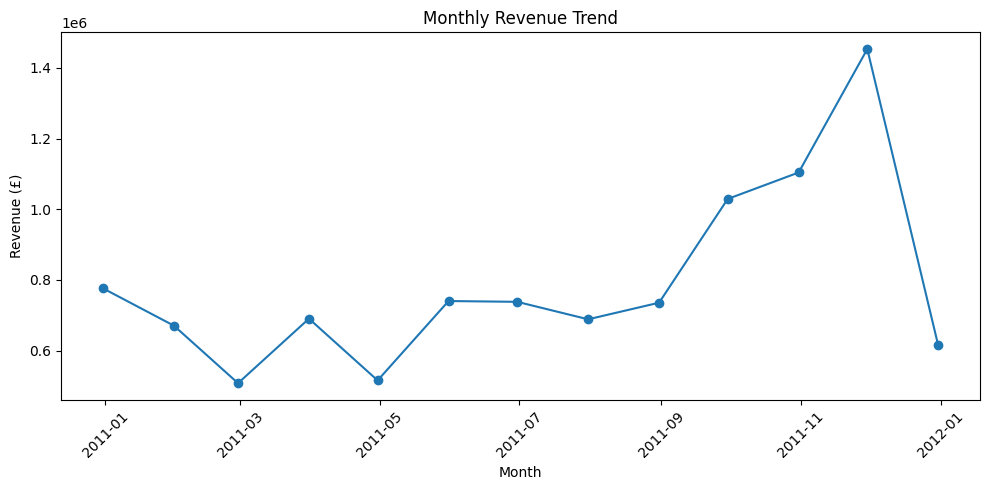

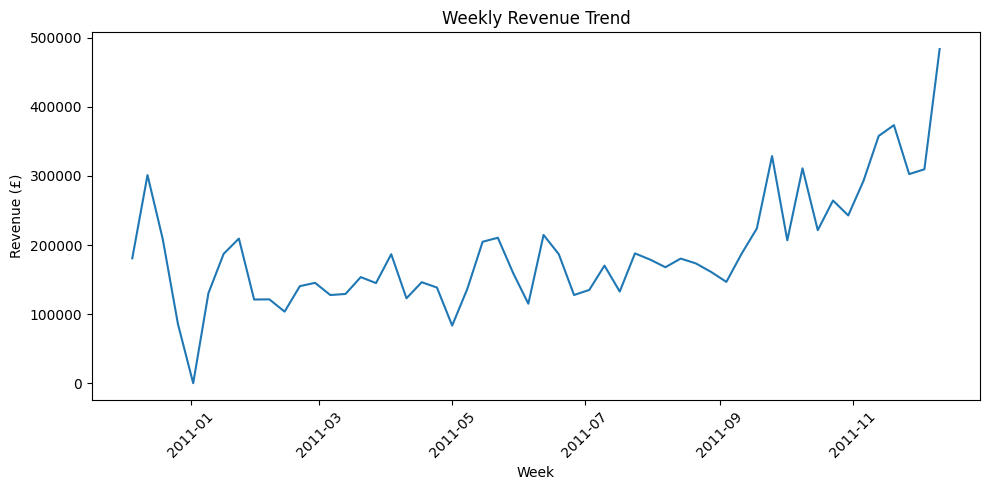

In [264]:
import matplotlib.pyplot as plt

time_indexed_sales, monthly_revenue, weekly_revenue = summarizer.group_by_time(part_d_df)

print("Monthly revenue trend:")
display(monthly_revenue)

print("\nWeekly revenue trend sample:")
display(weekly_revenue.head(10))

plt.figure(figsize=(10, 5))
plt.plot(monthly_revenue["invoice_date"], monthly_revenue["monthly_revenue"], marker="o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(weekly_revenue["invoice_date"], weekly_revenue["weekly_revenue"])
plt.title("Weekly Revenue Trend")
plt.xlabel("Week")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## PHASE E · Combine
This section recombines the cleaned data and enriches it with the region lookup table used later in the analysis.

### 3.20 Concatenating
Split the cleaned data into two periods, then concatenate them back together to simulate combining separate extracts.

In [265]:
class DataCombiner:
    """Phase E — recombine the cleaned data and enrich it with the region lookup table."""

    def concat_periods(self, df, date_column="invoice_date"):
        """3.20 Split the cleaned data into two half-year periods, then concat them back together."""
        out = df.copy()
        out[date_column] = pd.to_datetime(out[date_column], errors="coerce")

        min_date = out[date_column].min()
        max_date = out[date_column].max()
        split_date = min_date + (max_date - min_date) / 2

        first_half = out[out[date_column] < split_date].copy()
        second_half = out[out[date_column] >= split_date].copy()


        combined = pd.concat([first_half, second_half], ignore_index=True)

        summary = pd.DataFrame({
            "period": ["first_half", "second_half", "combined", "original"],
            "rows": [len(first_half), len(second_half), len(combined), len(out)],
            "revenue": [
                first_half["revenue"].sum(),
                second_half["revenue"].sum(),
                combined["revenue"].sum(),
                out["revenue"].sum(),
            ],
        })

        return combined, first_half, second_half, split_date, summary

    def merge_region(self, df, lookup_table):
        """3.21 Merge the region lookup onto the data and compare inner vs left joins."""
        out = df.copy()

        inner_merged = out.merge(
            lookup_table, how="inner", left_on="country", right_on="Country"
        )
        left_merged = out.merge(
            lookup_table, how="left", left_on="country", right_on="Country"
        )

        # Tidy each result: drop the duplicate key column and snake_case the new column.
        for merged in (inner_merged, left_merged):
            merged.drop(columns=["Country"], inplace=True)
            merged.rename(columns={"Region": "region"}, inplace=True)

        unmatched = (
            left_merged[left_merged["region"].isna()]["country"]
            .value_counts()
            .reset_index()
        )
        unmatched.columns = ["country", "line_items"]

        comparison = pd.DataFrame({
            "join_type": ["inner", "left"],
            "rows": [len(inner_merged), len(left_merged)],
            "rows_with_region": [
                int(inner_merged["region"].notna().sum()),
                int(left_merged["region"].notna().sum()),
            ],
        })

        return left_merged, inner_merged, unmatched, comparison


combiner = DataCombiner()

# Split the cleaned completed-sales data into two periods and concatenate them back.
combined_df, first_half_df, second_half_df, split_date, period_summary = combiner.concat_periods(part_d_df)

print("Split date between the two periods:", split_date.date())
print("First half rows :", len(first_half_df))
print("Second half rows:", len(second_half_df))
print("Combined rows   :", len(combined_df), "| Original rows:", len(part_d_df))
print("Row counts match after concat:", len(combined_df) == len(part_d_df))

period_summary

Split date between the two periods: 2011-06-05
First half rows : 206584
Second half rows: 316131
Combined rows   : 522715 | Original rows: 522715
Row counts match after concat: True


,period,rows,revenue
0,first_half,206584,3.995233e+06
1,second_half,316131,6.270848e+06
2,combined,522715,1.026608e+07
3,original,522715,1.026608e+07


### 3.21 Merging
Merge the region lookup table into the cleaned data, then compare inner and left joins to note which countries do not match.

In [266]:
# Merge the region lookup into the recombined data and compare join strategies.
enriched_df, region_inner_df, unmatched_countries, join_comparison = combiner.merge_region(combined_df, lookup_table)

print("Inner vs left join comparison:")
display(join_comparison)

print()
print("Countries in the data with NO region match (left join leaves region = NaN):")
display(unmatched_countries)

# Inner join keeps only matched countries; left join keeps every sale and flags unmatched ones.
print()
print("Rows dropped by using an inner join instead of a left join:",
      len(enriched_df) - len(region_inner_df))

print()
print("Revenue by region (left-joined, region-enriched data):")
region_revenue = (
    enriched_df.groupby("region", dropna=False)["revenue"]
               .sum()
               .sort_values(ascending=False)
               .reset_index(name="total_revenue")
)
display(region_revenue)

# enriched_df is the final combined + region-enriched dataset used downstream.
enriched_df.head(5)

Inner vs left join comparison:


,join_type,rows,rows_with_region
0,inner,507319,507319
1,left,522715,507319



Countries in the data with NO region match (left join leaves region = NaN):


,country,line_items
0,Spain,2417
1,Netherlands,2322
2,Switzerland,1927
3,Portugal,1455
4,Australia,1180
5,Channel Islands,746
6,Italy,741
7,Finland,647
8,Cyprus,601
9,Austria,384



Rows dropped by using an inner join instead of a left join: 15396

Revenue by region (left-joined, region-enriched data):


,region,total_revenue
0,UK&IE,9013820.453
1,NaN,737778.490
2,Western Europe,426987.490
3,Nordics,87494.810


,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,revenue,description_clean,is_cancelled_invoice,region
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,White Hanging Heart T-Light Holder,False,UK&IE
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,White Metal Lantern,False,UK&IE
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,Cream Cupid Hearts Coat Hanger,False,UK&IE
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,Knitted Union Flag Hot Water Bottle,False,UK&IE
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,Red Woolly Hottie White Heart.,False,UK&IE


## Part 2 · Business Questions
Using the cleaned, completed-sales dataset, this section answers each business question with code, a table or number, and a short manager-facing interpretation.

The main dataset used here is `enriched_df`, which is the completed-sales data from Phase D plus the region lookup from Phase E. For the returns/cancellations and data-quality memo questions, this section also uses `raw_df` because those rows were intentionally removed from the completed-sales dataset.

In [ ]:
import math
import matplotlib.pyplot as plt

class BusinessQuestions:
    """Part 2 — answer the seven business questions from the cleaned completed-sales data."""

    def __init__(self, clean_df, raw_df=None):
        self.sales = clean_df.copy()
        self.raw = self._standardize_raw(raw_df) if raw_df is not None else None

        # Make sure revenue exists even if this class is reused before Phase D.
        if "revenue" not in self.sales.columns:
            self.sales["revenue"] = self.sales["quantity"] * self.sales["unit_price"]

        # Make sure date and region columns are analysis-ready.
        self.sales["invoice_date"] = pd.to_datetime(self.sales["invoice_date"], errors="coerce")
        if "region" not in self.sales.columns:
            self.sales["region"] = "Unmapped / Other"
        else:
            self.sales["region"] = self.sales["region"].fillna("Unmapped / Other")

    def _standardize_raw(self, raw_df):
        """Convert raw data column names to the same snake_case names used in cleaned data."""
        raw = raw_df.copy()
        raw = raw.rename(columns={
            "InvoiceNo": "invoice_no",
            "StockCode": "stock_code",
            "Description": "description",
            "Quantity": "quantity",
            "InvoiceDate": "invoice_date",
            "UnitPrice": "unit_price",
            "CustomerID": "customer_id",
            "Country": "country",
        })
        raw["invoice_date"] = pd.to_datetime(raw["invoice_date"], errors="coerce")
        return raw

    def _known_customer_mask(self, series):
        """Treat Unknown, missing, and blank customer IDs as unknown customers."""
        return series.notna() & (series.astype(str).str.strip() != "") & (series.astype(str) != "Unknown")

    def _product_name(self, series):
        """Return a stable representative description for each product."""
        cleaned = series.dropna().astype(str).str.strip().str.title()
        if cleaned.empty:
            return "Unknown Product"
        mode = cleaned.mode()
        return mode.iloc[0] if not mode.empty else cleaned.iloc[0]

    def seasonality(self):
        """1. Total revenue by month, peak month, and seasonal lift."""
        monthly = (
            self.sales
            .dropna(subset=["invoice_date"])
            .groupby(pd.Grouper(key="invoice_date", freq="ME"))
            .agg(
                total_revenue=("revenue", "sum"),
                invoice_count=("invoice_no", "nunique"),
                line_count=("stock_code", "count"),
            )
            .reset_index()
        )
        monthly["month"] = monthly["invoice_date"].dt.strftime("%Y-%m")

        total_revenue = self.sales["revenue"].sum()
        avg_monthly_revenue = monthly["total_revenue"].mean()
        peak = monthly.loc[monthly["total_revenue"].idxmax()]
        peak_lift_pct = ((peak["total_revenue"] - avg_monthly_revenue) / avg_monthly_revenue) * 100

        monthly["is_q4"] = monthly["invoice_date"].dt.month.isin([10, 11, 12])
        q4_avg = monthly.loc[monthly["is_q4"], "total_revenue"].mean()
        non_q4_avg = monthly.loc[~monthly["is_q4"], "total_revenue"].mean()
        q4_lift_pct = ((q4_avg - non_q4_avg) / non_q4_avg) * 100

        print(f"Total completed-sales revenue: £{total_revenue:,.2f}")
        print(f"Peak month: {peak['month']} with £{peak['total_revenue']:,.2f}")
        print(f"Peak month lift versus average month: {peak_lift_pct:.1f}%")
        print(f"Q4 average monthly revenue lift versus non-Q4 months: {q4_lift_pct:.1f}%")

        display(monthly[["month", "total_revenue", "invoice_count", "line_count"]])

        plt.figure(figsize=(10, 5))
        plt.plot(monthly["invoice_date"], monthly["total_revenue"], marker="o")
        plt.title("Monthly Revenue Trend")
        plt.xlabel("Month")
        plt.ylabel("Revenue (£)")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

        return monthly

    def best_sellers(self):
        """2. Top 10 products by revenue and by units sold."""
        product_summary = (
            self.sales
            .groupby("stock_code", dropna=False)
            .agg(
                description=("description_clean" if "description_clean" in self.sales.columns else "description", self._product_name),
                total_revenue=("revenue", "sum"),
                units_sold=("quantity", "sum"),
                avg_unit_price=("unit_price", "mean"),
                invoice_count=("invoice_no", "nunique"),
            )
            .reset_index()
        )

        top_revenue = product_summary.sort_values("total_revenue", ascending=False).head(10)
        top_units = product_summary.sort_values("units_sold", ascending=False).head(10)

        overlap = set(top_revenue["stock_code"]).intersection(set(top_units["stock_code"]))

        print("Top 10 products by revenue:")
        display(top_revenue)

        print("Top 10 products by units sold:")
        display(top_units)

        return top_revenue, top_units, product_summary

    def markets(self):
        """3. Outside the UK, rank countries and regions by revenue and distinct customers."""
        outside_uk = self.sales[self.sales["country"] != "United Kingdom"].copy()

        country_markets = (
            outside_uk
            .groupby("country", dropna=False)
            .agg(
                total_revenue=("revenue", "sum"),
                distinct_customers=("customer_id", lambda s: s[self._known_customer_mask(s)].nunique()),
                invoice_count=("invoice_no", "nunique"),
                line_count=("stock_code", "count"),
            )
            .sort_values(["total_revenue", "distinct_customers"], ascending=False)
            .reset_index()
        )

        region_markets = (
            outside_uk
            .groupby("region", dropna=False)
            .agg(
                total_revenue=("revenue", "sum"),
                distinct_customers=("customer_id", lambda s: s[self._known_customer_mask(s)].nunique()),
                invoice_count=("invoice_no", "nunique"),
                line_count=("stock_code", "count"),
            )
            .sort_values(["total_revenue", "distinct_customers"], ascending=False)
            .reset_index()
        )

        print("Most valuable non-UK countries:")
        display(country_markets.head(10))

        print("Most valuable non-UK regions:")
        display(region_markets)

        best_country = country_markets.iloc[0]

        plt.figure(figsize=(10, 5))
        plt.bar(country_markets.head(10)["country"].astype(str), country_markets.head(10)["total_revenue"])
        plt.title("Top Non-UK Markets by Revenue")
        plt.xlabel("Country")
        plt.ylabel("Revenue (£)")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

        return country_markets, region_markets

    def customer_concentration(self):
        """4. Top customers and top 1% revenue concentration."""
        known_sales = self.sales[self._known_customer_mask(self.sales["customer_id"])].copy()

        customer_spend = (
            known_sales
            .groupby("customer_id")
            .agg(
                total_spend=("revenue", "sum"),
                order_count=("invoice_no", "nunique"),
                line_count=("stock_code", "count"),
                primary_country=("country", lambda s: s.mode().iloc[0] if not s.mode().empty else s.iloc[0]),
            )
            .sort_values("total_spend", ascending=False)
            .reset_index()
        )

        top_10_customers = customer_spend.head(10)
        top_1pct_count = max(1, math.ceil(len(customer_spend) * 0.01))
        top_1pct_revenue = customer_spend.head(top_1pct_count)["total_spend"].sum()
        total_revenue = self.sales["revenue"].sum()
        top_1pct_share = top_1pct_revenue / total_revenue

        print("Top 10 customers by total spend:")
        display(top_10_customers)

        print(f"Known customers counted: {len(customer_spend):,}")
        print(f"Top 1% customer count: {top_1pct_count:,}")
        print(f"Top 1% revenue: £{top_1pct_revenue:,.2f}")
        print(f"Top 1% share of total completed-sales revenue: {top_1pct_share:.2%}")

        return top_10_customers, customer_spend, top_1pct_share

    def order_value(self):
        """5. Average order value overall and UK vs non-UK."""
        invoice_orders = (
            self.sales
            .groupby("invoice_no")
            .agg(
                order_revenue=("revenue", "sum"),
                country=("country", "first"),
                line_count=("stock_code", "count"),
            )
            .reset_index()
        )
        invoice_orders["market"] = np.where(invoice_orders["country"] == "United Kingdom", "UK", "Non-UK")

        aov_summary = (
            invoice_orders
            .groupby("market")
            .agg(
                mean_order_value=("order_revenue", "mean"),
            )
            .reset_index()
        )

        overall_aov = invoice_orders["order_revenue"].mean()

        print(f"Overall average order value: £{overall_aov:,.2f}")
        display(aov_summary)

        return invoice_orders, aov_summary
    def returns_and_cancellations(self):
        """6. How common are cancellations/returns, by count and by value?"""
        if self.raw is None:
            raise ValueError("raw_df is required for returns and cancellations.")

        raw = self.raw.copy()
        raw["is_return_or_cancel"] = (
            raw["invoice_no"].astype(str).str.startswith("C") | (raw["quantity"] <= 0)
        )
        raw["line_value_abs"] = (raw["quantity"] * raw["unit_price"]).abs()

        rc = raw[raw["is_return_or_cancel"]].copy()

        raw_rows = len(raw)
        rc_rows = len(rc)
        raw_invoices = raw["invoice_no"].nunique()
        rc_invoices = rc["invoice_no"].nunique()
        rc_value_abs = rc["line_value_abs"].sum()

        print("Returns / cancellations summary:")
        print(f"raw rows: {raw_rows:,}")
        print(f"return/cancellation rows: {rc_rows:,}")
        print(f"row share: {rc_rows / raw_rows:.2%}")
        print(f"raw invoices: {raw_invoices:,}")
        print(f"return/cancellation invoices: {rc_invoices:,}")
        print(f"invoice share: {rc_invoices / raw_invoices:.2%}")
        print(f"absolute value of returns/cancellations: £{rc_value_abs:,.2f}")

        top_products = (
            rc.groupby("stock_code", dropna=False)
            .agg(
                description=("description", self._product_name),
                rows=("invoice_no", "count"),
                value_abs=("line_value_abs", "sum"),
            )
            .sort_values("value_abs", ascending=False)
            .head(10)
            .reset_index()
        )

        top_customers = (
            rc[self._known_customer_mask(rc["customer_id"])]
            .groupby("customer_id")
            .agg(
                rows=("invoice_no", "count"),
                value_abs=("line_value_abs", "sum"),
            )
            .sort_values("value_abs", ascending=False)
            .head(10)
            .reset_index()
        )

        print("Top return/cancellation products:")
        display(top_products)

        print("Top return/cancellation customers:")
        display(top_customers)

        return top_products, top_customers


# Use the final region-enriched completed-sales dataset when available.
# Fall back to part_d_df if Phase E has not been run yet.
try:
    analysis_sales_df = enriched_df.copy()
except NameError:
    analysis_sales_df = part_d_df.copy()

bq = BusinessQuestions(clean_df=analysis_sales_df, raw_df=raw_df)


### 1. Seasonality
**Question:** What was total revenue for the year, and how does it break down by month? When is the peak trading season, and by how much does it lift sales?

Total completed-sales revenue: £10,266,081.24
Peak month: 2011-11 with £1,453,265.98
Peak month lift versus average month: 84.0%
Q4 average monthly revenue lift versus non-Q4 months: 40.6%


,month,total_revenue,invoice_count,line_count
0,2010-12,776314.950,1551,40838
1,2011-01,670639.460,1081,33909
2,2011-02,508081.540,1093,26749
3,2011-03,690591.840,1440,35317
4,2011-04,515899.661,1236,28756
5,2011-05,740472.330,1668,35745
6,2011-06,738233.990,1525,35529
7,2011-07,688802.671,1452,38206
8,2011-08,735770.220,1341,34121
9,2011-09,1029245.381,1819,48715


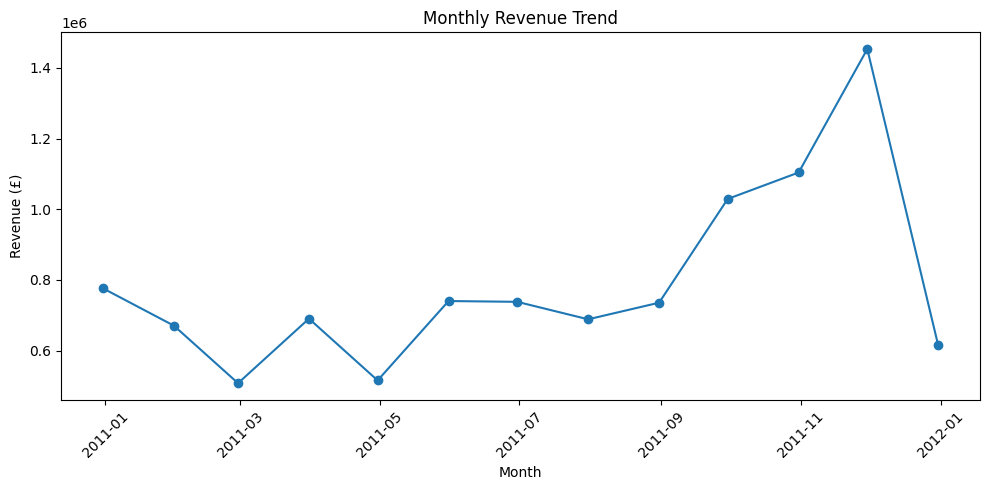

In [268]:
monthly_part2 = bq.seasonality()

### 2. Best Sellers
**Question:** Which 10 products earned the most revenue, and which 10 sold the most units? Are they the same list and what does any difference tell you about pricing?

In [269]:
top_revenue_products, top_units_products, product_summary = bq.best_sellers()

Top 10 products by revenue:


,stock_code,description,total_revenue,units_sold,avg_unit_price,invoice_count
1310,22423,Regency Cakestand 3 Tier,174156.54,13851,13.983936,1988
2465,23843,"Paper Craft , Little Birdie",168469.60,80995,2.080000,1
3407,85123A,White Hanging Heart T-Light Holder,104462.75,37641,3.117838,2198
2670,47566,Party Bunting,99445.23,18283,5.797928,1685
3387,85099B,Jumbo Bag Red Retrospot,94159.81,48371,2.486197,2089
2020,23166,Medium Ceramic Top Storage Jar,81700.92,78033,1.468480,247
1942,23084,Rabbit Night Light,66870.03,30739,2.386401,994
1006,22086,Paper Chain Kit 50'S Christmas,64875.59,19329,3.362331,1160
3194,84879,Assorted Colour Bird Ornament,58927.62,36362,1.722575,1455
2845,79321,Chilli Lights,54096.36,10302,6.795397,661


Top 10 products by units sold:


,stock_code,description,total_revenue,units_sold,avg_unit_price,invoice_count
2465,23843,"Paper Craft , Little Birdie",168469.60,80995,2.080000,1
2020,23166,Medium Ceramic Top Storage Jar,81700.92,78033,1.468480,247
1109,22197,Popcorn Holder,51334.47,56898,1.043554,1392
2909,84077,World War 2 Gliders Asstd Designs,13814.01,54951,0.320728,535
3387,85099B,Jumbo Bag Red Retrospot,94159.81,48371,2.486197,2089
3407,85123A,White Hanging Heart T-Light Holder,104462.75,37641,3.117838,2198
439,21212,Pack Of 72 Retrospot Cake Cases,21246.45,36396,0.761206,1320
3194,84879,Assorted Colour Bird Ornament,58927.62,36362,1.722575,1455
1942,23084,Rabbit Night Light,66870.03,30739,2.386401,994
1374,22492,Mini Paint Set Vintage,16937.82,26633,0.785026,380


There are 6 products that overlap between the two top-10 listsProducts that rank high by revenue but not by units are higher-priced products. Products that rank high by units but not revenue are lower-priced volume sellers.

### 3. Markets
**Question:** Outside the UK, which countries and regions are most valuable by revenue and by number of distinct customers? Where would you expand?

Most valuable non-UK countries:


,country,total_revenue,distinct_customers,invoice_count,line_count
0,Netherlands,283889.34,9,93,2322
1,Ireland,276090.86,3,284,7874
2,Germany,205381.15,94,443,8643
3,France,184679.00,87,383,8087
4,Australia,138103.81,9,56,1180
5,Spain,55706.56,30,88,2417
6,Switzerland,53065.60,21,50,1927
7,Japan,37416.37,8,19,321
8,Belgium,36927.34,25,98,1935
9,Sweden,36828.83,8,34,427


Most valuable non-UK regions:


,region,total_revenue,distinct_customers,invoice_count,line_count
0,Unmapped / Other,737778.49,186,583,15396
1,Western Europe,426987.49,206,924,18665
2,UK&IE,276090.86,3,284,7874
3,Nordics,87494.81,27,84,1842


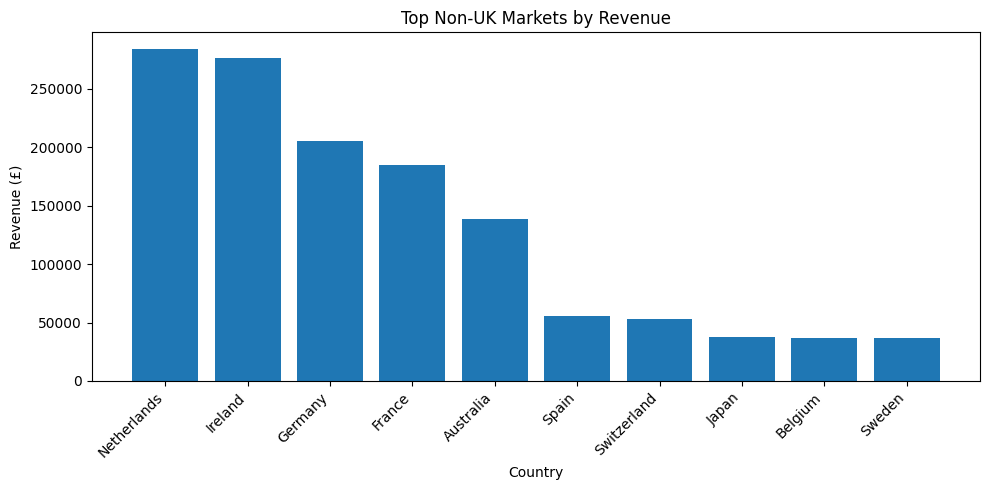

In [270]:
country_markets, region_markets = bq.markets()

It is better to prioritize Netherlands because it has the highest non-UK revenue in the cleaned data. Also consider countries with both high revenue and a broad customer base, not just one large buyer.

### 4. Customer Concentration

Question: Who are the top 10 customers by total spend, and what share of total revenue
do the top 1% of customers account for? Is this a wholesale-driven business?

In [271]:
top_10_customers, customer_spend, top_1pct_share = bq.customer_concentration()

Top 10 customers by total spend:


,customer_id,total_spend,order_count,line_count,primary_country
0,14646.0,279138.02,72,2060,Netherlands
1,18102.0,259657.30,60,431,United Kingdom
2,17450.0,194390.79,46,336,United Kingdom
3,16446.0,168472.50,2,3,United Kingdom
4,14911.0,140336.83,199,5668,Ireland
5,12415.0,124564.53,20,713,Australia
6,14156.0,117210.08,55,1395,Ireland
7,17511.0,91062.38,31,963,United Kingdom
8,12346.0,77183.60,1,1,United Kingdom
9,16029.0,72708.09,62,240,United Kingdom


Known customers counted: 4,334
Top 1% customer count: 44
Top 1% revenue: £2,818,458.52
Top 1% share of total completed-sales revenue: 27.45%


Since the top 1\% of customers support 27.45\% of the entire business's revenue, the business is dependant on a small number of high-value repeat buyers, which is typical of a wholesale-driven business.

### 5. Order Value

Question: What is the average order value (revenue per invoice), and how does it differ between UK
and non-UK customers?

In [272]:
invoice_orders, aov_summary = bq.order_value()

Overall average order value: £519.04


,market,mean_order_value
0,Non-UK,815.120880
1,UK,488.032261


### 6. Returns & Cancellations

Question: How common are cancellations/returns, by count and by value? Which products
or customers are most associated with them?

In [273]:
top_products, top_customers = bq.returns_and_cancellations()

Returns / cancellations summary:
raw rows: 541,909
return/cancellation rows: 10,624
row share: 1.96%
raw invoices: 25,900
return/cancellation invoices: 5,172
invoice share: 19.97%
absolute value of returns/cancellations: £896,812.49
Top return/cancellation products:


,stock_code,description,rows,value_abs
0,AMAZONFEE,Amazon Fee,32,235281.59
1,23843,"Paper Craft , Little Birdie",1,168469.60
2,M,Manual,244,146784.46
3,23166,Medium Ceramic Top Storage Jar,10,77479.64
4,POST,Postage,126,11871.24
5,22423,Regency Cakestand 3 Tier,184,9722.55
6,CRUK,Cruk Commission,16,7933.43
7,BANK CHARGES,Bank Charges,25,7340.64
8,85123A,White Hanging Heart T-Light Holder,43,6624.30
9,21108,Fairy Cake Flannel Assorted Colour,3,6591.42


Top return/cancellation customers:


,customer_id,rows,value_abs
0,16446.0,1,168469.60
1,12346.0,1,77183.60
2,15098.0,2,39267.00
3,16029.0,32,30032.23
4,15749.0,5,22998.40
5,12744.0,7,12158.90
6,14911.0,226,11252.44
7,12931.0,20,8593.15
8,12536.0,12,8495.01
9,14096.0,17,8043.88


### 7. Data-quality memo

Question: What share of the raw rows did you remove or repair (missing IDs, duplicates,
cancellations, bad prices)? What assumptions did you make, and would you trust this dataset for a board report? Why or why not?

Answer: I removed 12,519 of 540,455 raw rows, which is 2.32%. I fixed missing customer IDs by marking them as `Unknown` and removed cancellations, bad prices, zero or negative quantities, non-product lines, and duplicate rows. I would use this dataset for general analysis, but I would not use it alone for a board report because some cleaning choices are based on judgment and some customer data is missing.
